In [23]:
import numpy as np
import pandas as pd
import scanpy as sc
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import pearsonr
from sklearn.dummy import DummyRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_squared_error
from sklearn.preprocessing import StandardScaler

In [9]:
## load data
# Single-cell-data 
adata_pre = sc.read_h5ad('../data/frangieh/adata_preprocessed.h5ad')

# LFC data (711 rows x 2000 HVGs)
adata_lfc = sc.read_h5ad('../data/frangieh/log_fold_change_adata_hvg.h5ad')

In [10]:
# calculate basal expression profile from control cells (pertubation = control in each of the 3 conditions)
ctrl_cells = adata_pre[adata_pre.obs['perturbation'] == 'control']

df_ctrl = ctrl_cells.to_df()
df_ctrl['condition'] = ctrl_cells.obs['condition'].values

# mean basal expression per condition (3 rows x ~18.000 genes)
mean_ctrl_by_cond = df_ctrl.groupby('condition').mean()

/tmp/ipykernel_11313/944471712.py:8: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  mean_ctrl_by_cond = df_ctrl.groupby('condition').mean()


In [11]:
# create feature matrix X
# Feature 1: Basale KO-Expression for each row
basal_ko_values = []
for _, row in adata_lfc.obs.iterrows():
    cond = row['condition']
    ko_gene = row['perturbation']
    
    # Wert abfragen (Fallback 0.0 falls nicht in Matrix vorhanden)
    val = mean_ctrl_by_cond.loc[cond, ko_gene] if ko_gene in mean_ctrl_by_cond.columns else 0.0
    basal_ko_values.append(val)

# Feature 2: Condition One-Hot-Encoding
cond_dummies = pd.get_dummies(adata_lfc.obs['condition'], dtype=float)

# Shape: 711 rows x 4 columns
X_features = np.column_stack([basal_ko_values, cond_dummies.values])

feature_names = ['basal_ko_expression'] + list(cond_dummies.columns)

In [13]:
# scale features 
scaler = StandardScaler()
X = scaler.fit_transform(X_features)

# target matrix y: LFCs of 2000 HVGs
y = adata_lfc.X

In [15]:
# save features 
adata_lfc.obsm['X_basal'] = X
adata_lfc.uns['feature_names_basal'] = feature_names


print(f"X (Features) Shape: {X.shape}")  # expected: (711, 4)
print(f"y (Targets)  Shape: {y.shape}")  # expected: (711, 2000)
print(f"used Feature-names: {feature_names}")

X (Features) Shape: (711, 4)
y (Targets)  Shape: (711, 2000)
used Feature-names: ['basal_ko_expression', 'Co-culture', 'Control', 'IFNγ']


In [18]:
all_results = []
conditions = ['Control', 'IFNγ', 'Co-culture']

for strategy_name, selected_50 in adata_lfc.uns['subsets'].items():
  # filter 50 genes and 40/10 split
  adata_50 = adata_lfc[adata_lfc.obs['perturbation'].isin(selected_50)].copy()

  np.random.seed(42)
  test_genes_10 = np.random.choice(selected_50, size=10, replace=False).tolist()
  is_test = adata_50.obs['perturbation'].isin(test_genes_10).values

  X_50 = adata_50.obsm['X_basal']
  y_50 = adata_50.X

  X_train, y_train = X_50[~is_test], y_50[~is_test]
  X_test, y_test = X_50[is_test], y_50[is_test]
  obs_test = adata_50.obs[is_test].reset_index(drop=True)

  # fit models 
  # (A) Baseline
  dummy = DummyRegressor(strategy='mean')
  dummy.fit(X_train, y_train)
  y_pred_dummy = dummy.predict(X_test)

  # (B) Ridge Regression 
  ridge = Ridge(alpha=1.0)
  ridge.fit(X_train, y_train)
  y_pred_ridge = ridge.predict(X_test)

  # (C) Random Forest 
  rf = RandomForestRegressor(n_estimators=100, max_depth=5, random_state=42)
  rf.fit(X_train, y_train)
  y_pred_rf = rf.predict(X_test)

  # metrices
  for cond in conditions:
    cond_mask = (obs_test['condition'] == cond).values
    y_true_cond = y_test[cond_mask]

    # MSE
    mse_dummy = mean_squared_error(y_true_cond, y_pred_dummy[cond_mask])
    mse_ridge = mean_squared_error(y_true_cond, y_pred_ridge[cond_mask])
    mse_rf = mean_squared_error(y_true_cond, y_pred_rf[cond_mask])

    # Pearson Korrelation
    corr_dummy = np.nanmean([
        pearsonr(y_true_cond[i], y_pred_dummy[cond_mask][i])[0]
        for i in range(len(y_true_cond))
    ])
    corr_ridge = np.nanmean([
        pearsonr(y_true_cond[i], y_pred_ridge[cond_mask][i])[0]
        for i in range(len(y_true_cond))
    ])
    corr_rf = np.nanmean([
        pearsonr(y_true_cond[i], y_pred_rf[cond_mask][i])[0]
        for i in range(len(y_true_cond))
    ])

    all_results.append({
        'Strategy': strategy_name,
        'Condition': cond,
        'MSE Baseline': mse_dummy,
        'MSE Ridge': mse_ridge,
        'MSE RF': mse_rf,
        'Pearson r Baseline': 0.0 if np.isnan(corr_dummy) else corr_dummy,
        'Pearson r Ridge': corr_ridge,
        'Pearson r RF': corr_rf,
    })

df_all_results = pd.DataFrame(all_results)
df_all_results

,Strategy,Condition,MSE Baseline,MSE Ridge,MSE RF,Pearson r Baseline,Pearson r Ridge,Pearson r RF
0,essentiality,Control,0.002674,0.002211,0.002368,0.820945,0.845260,0.833863
1,essentiality,IFNγ,0.003773,0.003657,0.002656,0.719343,0.731196,0.755832
2,essentiality,Co-culture,0.005307,0.005015,0.003430,0.519922,0.534712,0.564611
3,hallmark_pathways,Control,0.006292,0.006323,0.007366,0.625427,0.634087,0.568787
4,hallmark_pathways,IFNγ,0.004479,0.004489,0.004709,0.651371,0.654656,0.640503
5,hallmark_pathways,Co-culture,0.006473,0.006469,0.006326,0.544047,0.556497,0.552664
6,highest_lfc,Control,0.010704,0.010669,0.011242,0.506063,0.510016,0.459006
7,highest_lfc,IFNγ,0.013173,0.012705,0.012621,0.185231,0.215927,0.227492
8,highest_lfc,Co-culture,0.011389,0.011364,0.011603,0.270836,0.272649,0.259442
9,leiden_clusters,Control,0.004528,0.004270,0.004554,0.669358,0.690551,0.679563


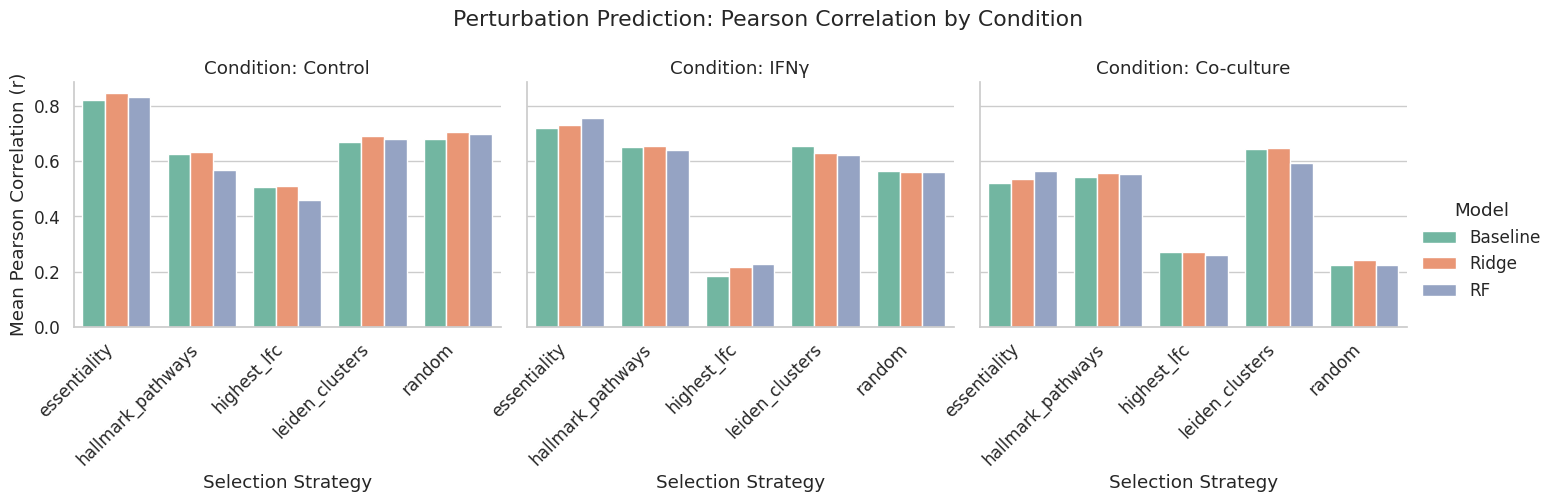

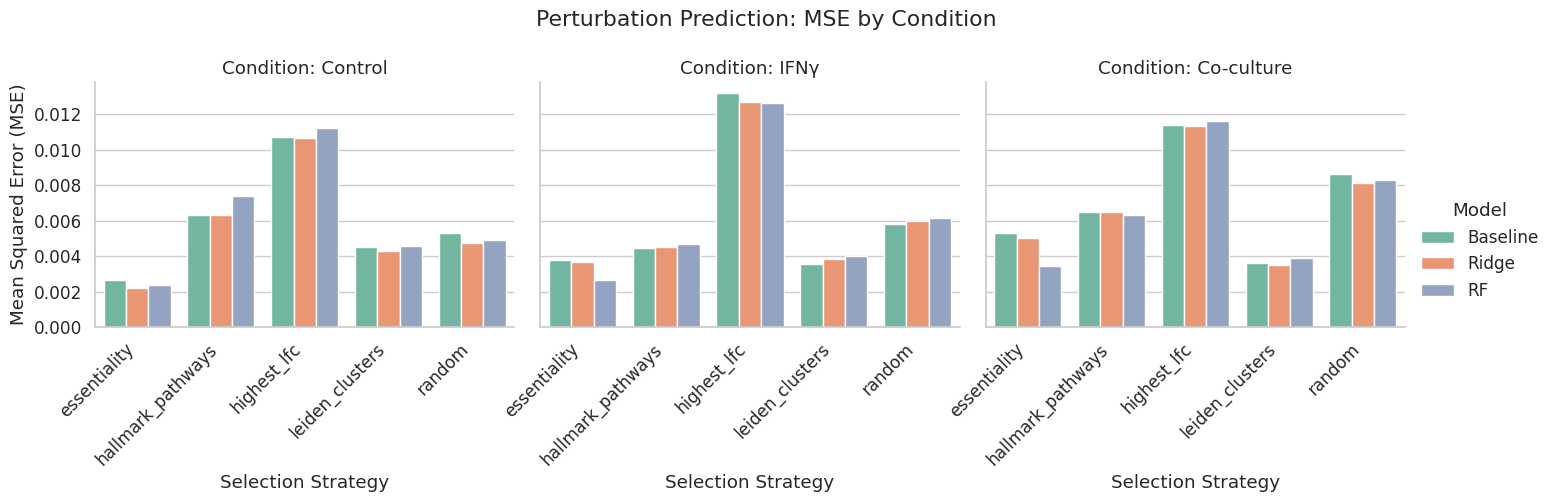

In [20]:
## visualization

df_pearson = df_all_results.melt(
    id_vars=['Strategy', 'Condition'],
    value_vars=['Pearson r Baseline', 'Pearson r Ridge', 'Pearson r RF'],
    var_name='Model',
    value_name='Pearson_r',
)
df_pearson['Model'] = df_pearson['Model'].str.replace('Pearson r ', '')

df_mse = df_all_results.melt(
    id_vars=['Strategy', 'Condition'],
    value_vars=['MSE Baseline', 'MSE Ridge', 'MSE RF'],
    var_name='Model',
    value_name='MSE',
)
df_mse['Model'] = df_mse['Model'].str.replace('MSE ', '')

sns.set_theme(style='whitegrid', font_scale=1.1)

g1 = sns.catplot(
    data=df_pearson,
    x='Strategy',
    y='Pearson_r',
    hue='Model',
    col='Condition',
    kind='bar',
    palette='Set2',
    height=4,
    aspect=1.2,
)
g1.set_axis_labels('Selection Strategy', 'Mean Pearson Correlation (r)')
g1.set_titles(col_template='Condition: {col_name}')
g1.set_xticklabels(rotation=45, ha='right')
g1.fig.subplots_adjust(top=0.8)
g1.fig.suptitle('Perturbation Prediction: Pearson Correlation by Condition')
plt.show()

g2 = sns.catplot(
    data=df_mse,
    x='Strategy',
    y='MSE',
    hue='Model',
    col='Condition',
    kind='bar',
    palette='Set2',
    height=4,
    aspect=1.2,
)
g2.set_axis_labels('Selection Strategy', 'Mean Squared Error (MSE)')
g2.set_titles(col_template='Condition: {col_name}')
g2.set_xticklabels(rotation=45, ha='right')
g2.fig.subplots_adjust(top=0.8)
g2.fig.suptitle('Perturbation Prediction: MSE by Condition')
plt.show()